In [1]:
import os
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc7 import *

In [2]:
## Try running the optimizer with no identifiability
## See what the order permutations are for the top N exploration samples
## Reoptimize on just that discrete set of permutations
## See which one wins out

In [3]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [4]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [5]:
# Initialize X and Y
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [11]:
# Make the permutation matrices
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))#.transpose(0,2,3,1)

P = tf.one_hot(
    perm_combos,
    3,
    axis=-1,
)
P = tf.transpose(P, (0,1,2,4,3))

P = tf.where(P == 1.0, 
                  tf.ones_like(P) * 10.0,   # large positive
                  tf.ones_like(P) * -10.0)  # large negative

In [21]:
perm_combos[0]

array([[[0, 1, 2],
        [0, 2, 1]],

       [[0, 1, 2],
        [1, 0, 2]],

       [[0, 1, 2],
        [1, 2, 0]],

       [[0, 1, 2],
        [2, 0, 1]],

       [[0, 1, 2],
        [2, 1, 0]],

       [[0, 2, 1],
        [1, 0, 2]],

       [[0, 2, 1],
        [1, 2, 0]]])

In [14]:
model = SGCCircuit(bounds=param_bounds, enforce_permutation=P[:2])
model.initialize_random_parameters(n_v1=2,n_lgn=3,n_sample=2)
optimizer = Optimize(model, epochs=100, loss_threshold=0)
optimizer.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002367C7F6F10>
Training step = 0, N_exploration_samples = 2,
min_loss = 3.3474695682525635
med_loss = 4.546298980712891
max_loss = 5.745128154754639



<tf.Tensor: shape=(100, 2), dtype=float16, numpy=
array([[5.746, 3.348],
       [5.727, 3.334],
       [5.71 , 3.318],
       [5.695, 3.305],
       [5.676, 3.291],
       [5.66 , 3.277],
       [5.645, 3.262],
       [5.625, 3.248],
       [5.61 , 3.234],
       [5.594, 3.22 ],
       [5.58 , 3.207],
       [5.562, 3.193],
       [5.543, 3.18 ],
       [5.527, 3.166],
       [5.51 , 3.152],
       [5.496, 3.139],
       [5.48 , 3.125],
       [5.465, 3.111],
       [5.45 , 3.1  ],
       [5.43 , 3.086],
       [5.414, 3.072],
       [5.4  , 3.059],
       [5.383, 3.047],
       [5.367, 3.033],
       [5.35 , 3.02 ],
       [5.336, 3.008],
       [5.32 , 2.994],
       [5.305, 2.982],
       [5.293, 2.969],
       [5.277, 2.957],
       [5.26 , 2.943],
       [5.246, 2.932],
       [5.23 , 2.918],
       [5.215, 2.906],
       [5.2  , 2.895],
       [5.188, 2.883],
       [5.17 , 2.87 ],
       [5.156, 2.857],
       [5.14 , 2.846],
       [5.13 , 2.834],
       [5.113, 2.822],
       

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

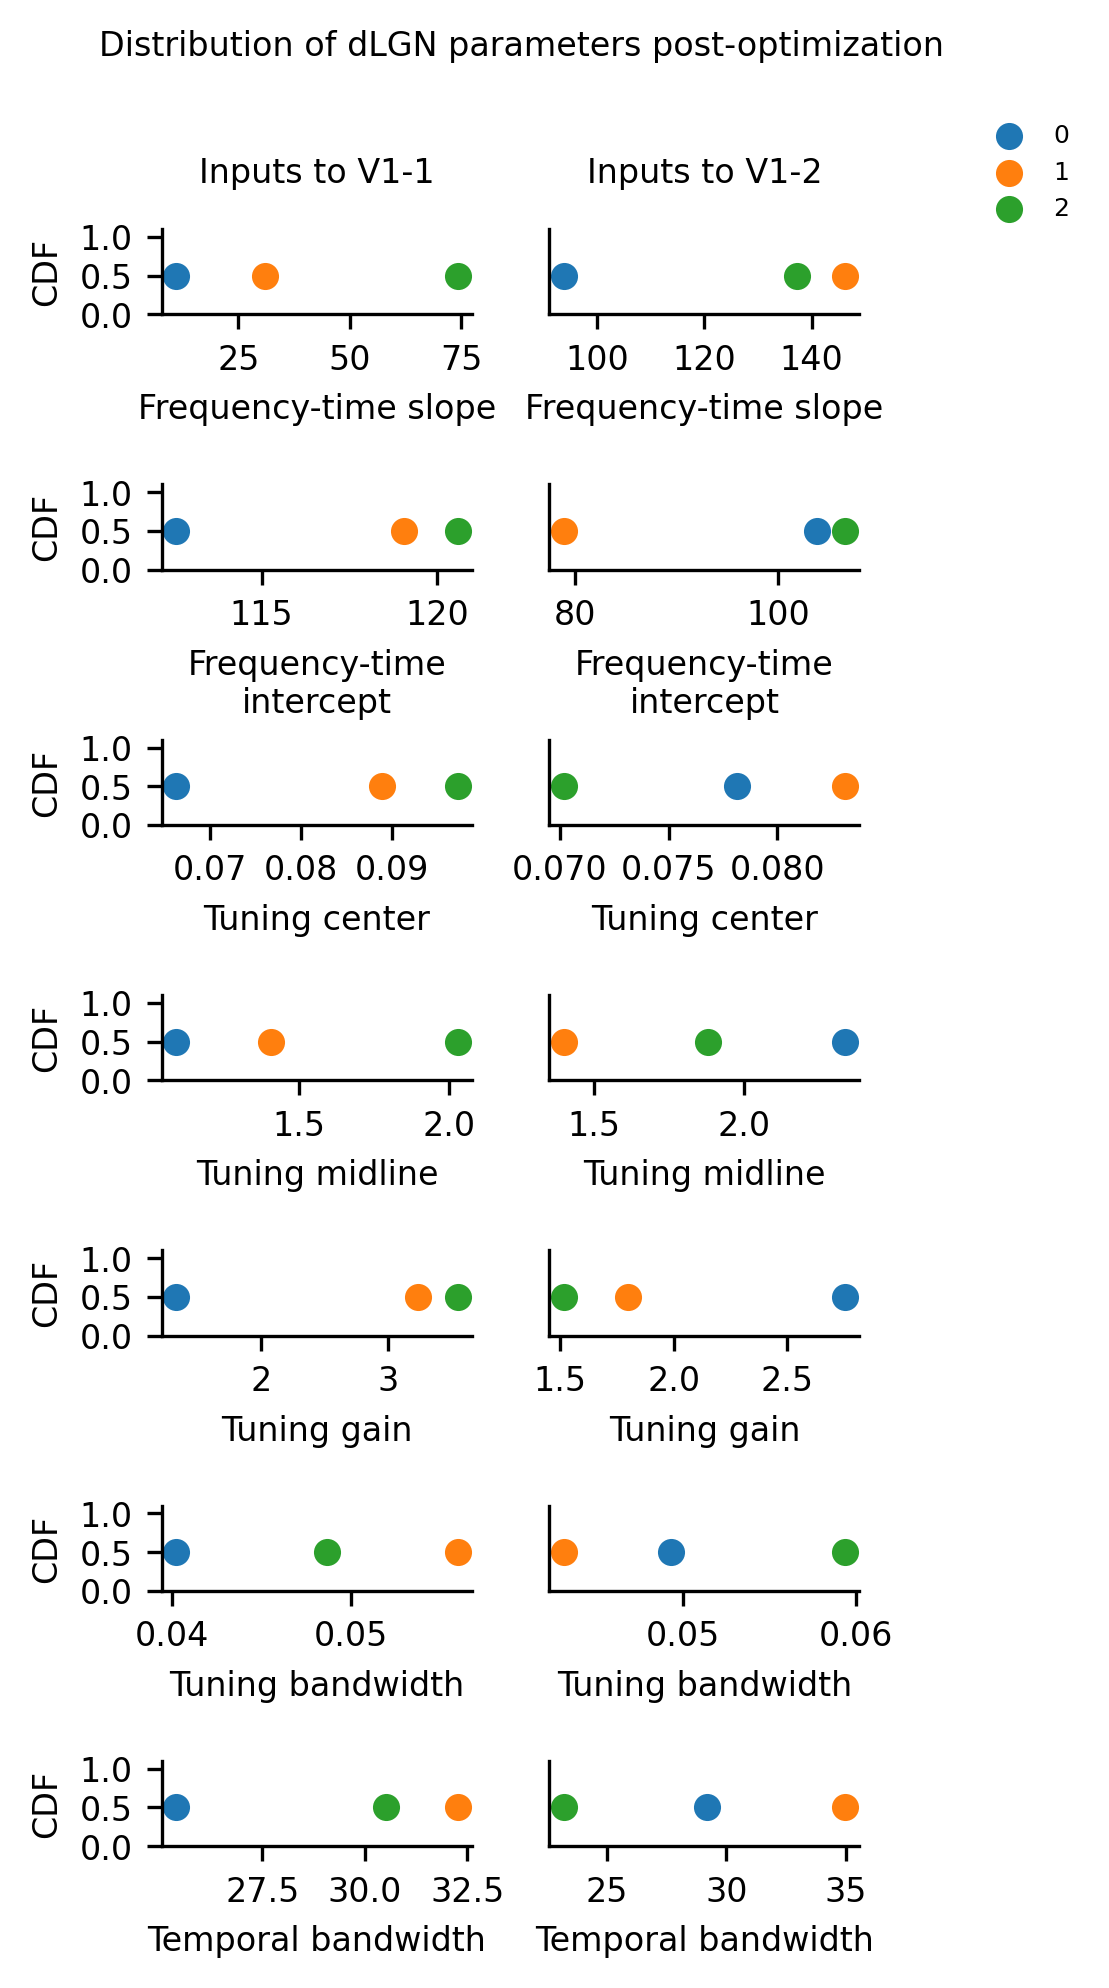

In [16]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model.params['dLGN_params'][0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

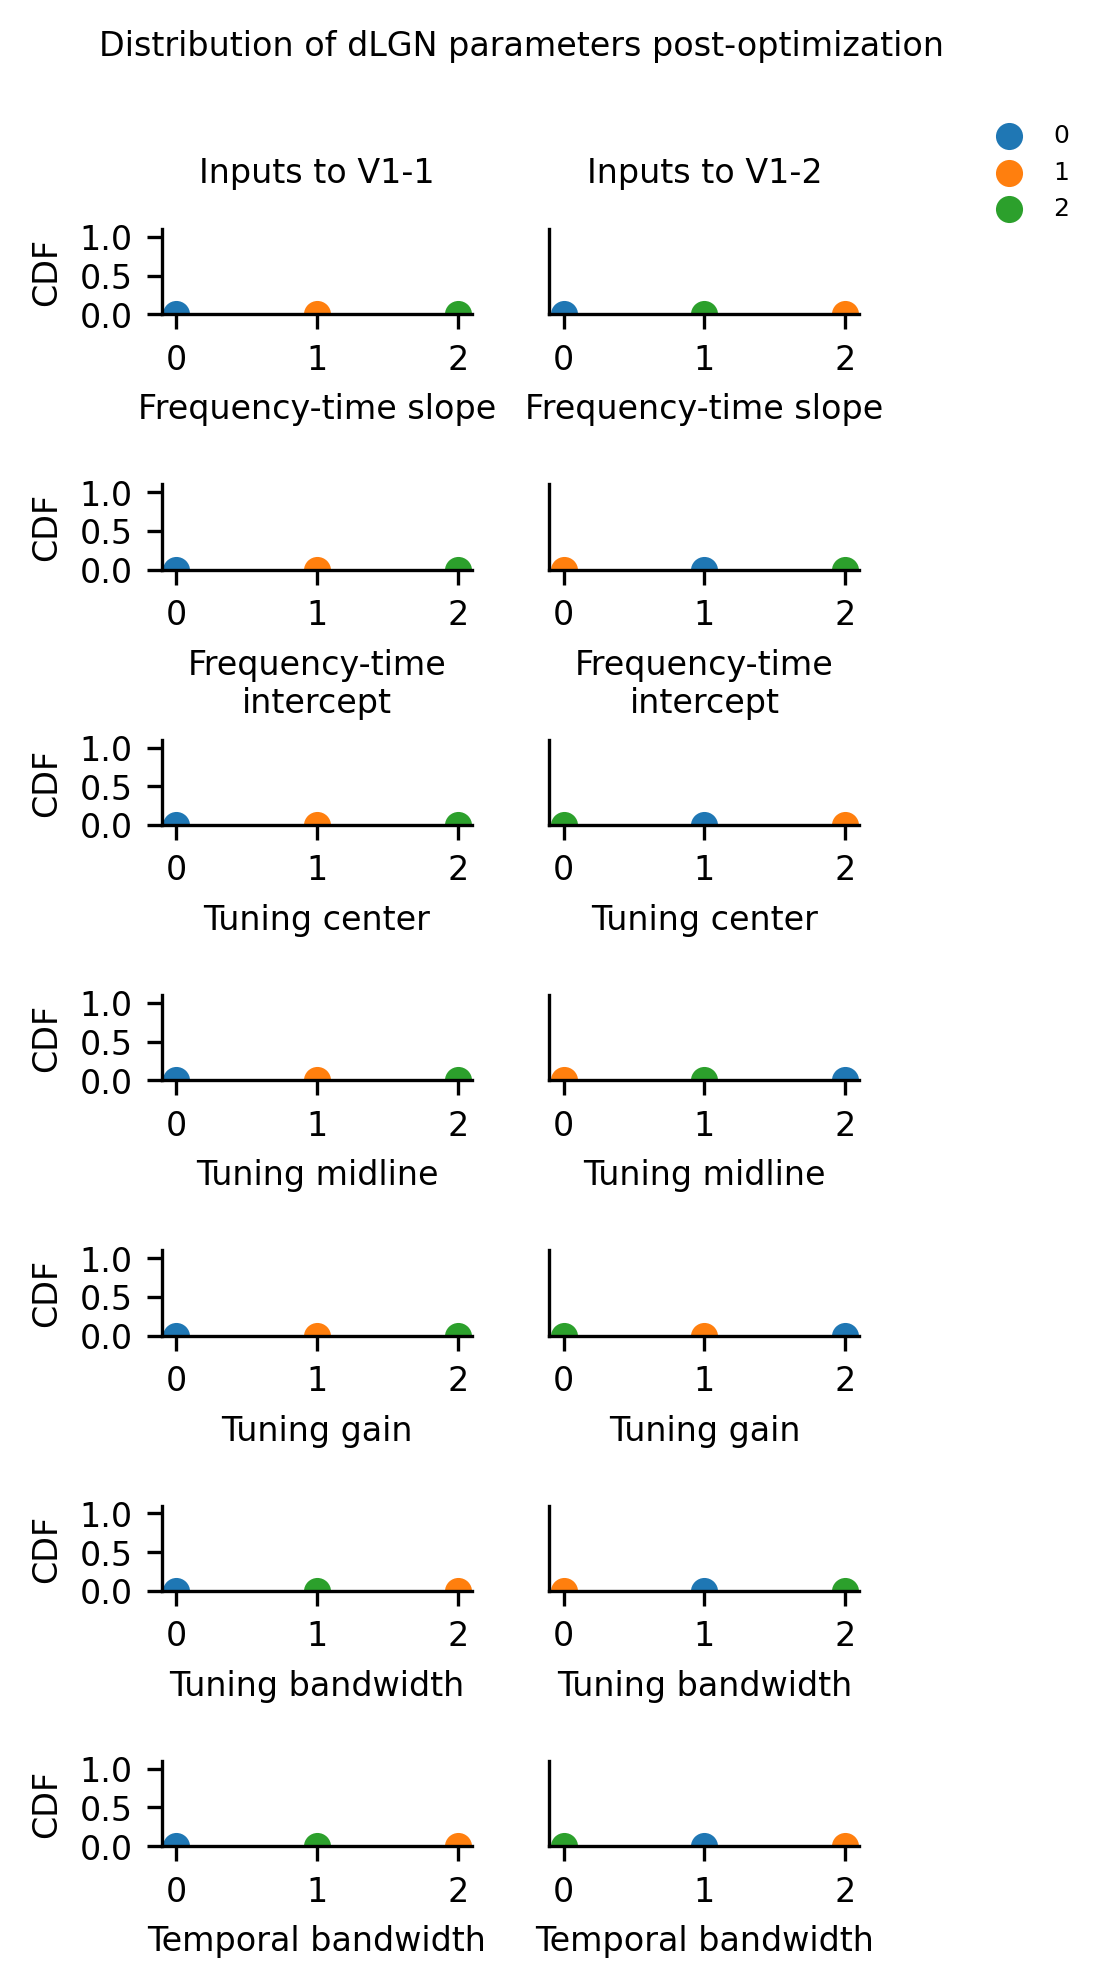

In [17]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(perm_combos[0, row, u, i], [0], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [ ]:
//